In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import TimeDistributed, LSTM, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# --- 1. CONFIGURATION ---
SEQUENCE_LENGTH = 16
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 8
CLASS_NAMES = ["NonViolence", "Violence"]

# --- 2. AUTOMATIC DATA PATH FINDING ---
# This looks into /kaggle/input and finds exactly where your folders are
DATASET_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'NonViolence' in dirs and 'Violence' in dirs:
        DATASET_DIR = root
        break

if not DATASET_DIR:
    raise Exception("❌ Dataset not found! Make sure 'Real Life Violence Situations Data' is added to Input.")
else:
    print(f"✅ Data located at: {DATASET_DIR}")

# --- 3. FRAME EXTRACTION FUNCTION ---
def extract_frames(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0: return None
    
    interval = max(1, total_frames // SEQUENCE_LENGTH)
    for i in range(SEQUENCE_LENGTH):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * interval)
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, IMAGE_SIZE)
        frame = preprocess_input(frame) # Crucial MobileNet scaling
        frames.append(frame)
    cap.release()
    return np.array(frames) if len(frames) == SEQUENCE_LENGTH else None

# --- 4. DATA GENERATOR (Prevents MemoryError) ---
class VideoGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=BATCH_SIZE):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.paths))

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            frames = extract_frames(self.paths[i])
            if frames is not None:
                X.append(frames)
                y.append(self.labels[i])
        return np.array(X), np.array(y)

# --- 5. PREPARE PATHS ---
all_paths, all_labels = [], []
for label, name in enumerate(CLASS_NAMES):
    folder = os.path.join(DATASET_DIR, name)
    # Using 400 per class to keep training time reasonable on Kaggle
    files = [os.path.join(folder, f) for f in os.listdir(folder)][:1000]
    for f in files:
        all_paths.append(f)
        all_labels.append(to_categorical(label, num_classes=2))

train_p, val_p, train_l, val_l = train_test_split(all_paths, all_labels, test_size=0.2, shuffle=True)
train_gen = VideoGenerator(train_p, train_l)
val_gen = VideoGenerator(val_p, val_l)

# --- 6. BUILD & TRAIN MODEL ---
mobilenet = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMAGE_SIZE, 3))
mobilenet.trainable = False

model = Sequential([
    Input(shape=(SEQUENCE_LENGTH, *IMAGE_SIZE, 3)),
    TimeDistributed(mobilenet),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(64),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=10)

# --- 7. PREDICTION ON UNSEEN VIDEO ---
def predict_video(path):
    frames = extract_frames(path)
    if frames is not None:
        # Add batch dimension: (1, 16, 160, 160, 3)
        pred = model.predict(np.expand_dims(frames, axis=0), verbose=0)
        idx = np.argmax(pred)
        print(f"🎬 Result: {CLASS_NAMES[idx]} ({np.max(pred)*100:.2f}%)")

# Test on the first video of the validation set
predict_video(val_p[0])

2026-02-08 17:02:42.605110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770570162.781732      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770570162.834631      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770570163.274696      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770570163.274737      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770570163.274740      55 computation_placer.cc:177] computation placer alr

✅ Data located at: /kaggle/input/real-life-violence-situations-dataset/real life violence situations/Real Life Violence Dataset


I0000 00:00:1770570176.164626      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

200/200 ━━━━━━━━━━━━━━━━━━━━ 1102s 6s/step - accuracy: 0.9968 - loss: 0.0124 - val_accuracy: 0.9525 - val_loss: 0.2109
Epoch 9/10
144/200 ━━━━━━━━━━━━━━━━━━━━ 4:06 4s/step - accuracy: 0.9853 - loss: 0.0273

[h264 @ 0x7b2a602da240] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2a602da240] error while decoding MB 98 31
[h264 @ 0x7b2a602da240] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2a602da240] error while decoding MB 98 31
[h264 @ 0x7b2a602da240] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2a602da240] error while decoding MB 98 31
[h264 @ 0x7b2a602da240] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2a602da240] error while decoding MB 98 31


200/200 ━━━━━━━━━━━━━━━━━━━━ 1103s 6s/step - accuracy: 0.9832 - loss: 0.0338 - val_accuracy: 0.9450 - val_loss: 0.1625
Epoch 10/10
 20/200 ━━━━━━━━━━━━━━━━━━━━ 16:10 5s/step - accuracy: 1.0000 - loss: 0.0186

[h264 @ 0x7b2ac006b2c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2ac006b2c0] error while decoding MB 98 31
[h264 @ 0x7b2ac006b2c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2ac006b2c0] error while decoding MB 98 31
[h264 @ 0x7b2ac006b2c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2ac006b2c0] error while decoding MB 98 31
[h264 @ 0x7b2ac006b2c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x7b2ac006b2c0] error while decoding MB 98 31


200/200 ━━━━━━━━━━━━━━━━━━━━ 1111s 6s/step - accuracy: 0.9917 - loss: 0.0313 - val_accuracy: 0.9575 - val_loss: 0.1805
🎬 Result: Violence (99.99%)


Gathering predictions (this may take a minute)...


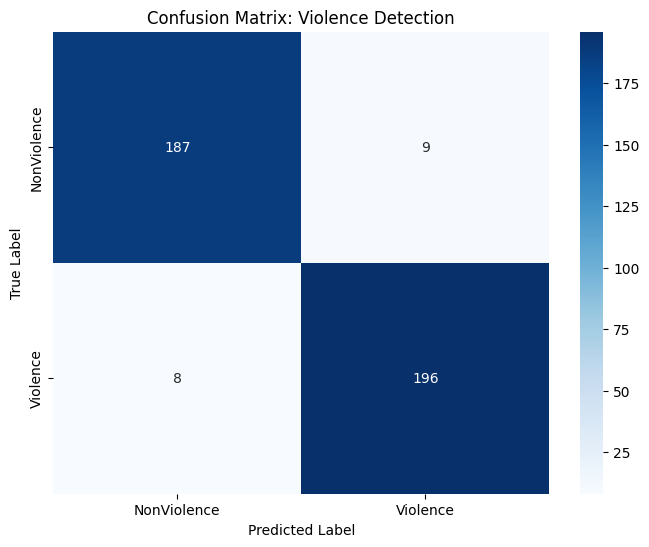


Classification Report:
              precision    recall  f1-score   support

 NonViolence       0.96      0.95      0.96       196
    Violence       0.96      0.96      0.96       204

    accuracy                           0.96       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_kaggle_confusion_matrix(model, generator):
    print("Gathering predictions (this may take a minute)...")
    
    y_true = []
    y_pred = []

    # Loop through the generator to get all labels and predictions
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = model.predict(X_batch, verbose=0)
        
        # Convert from One-Hot [0,1] to single index (0 or 1)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    # 1. Create the Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Violence Detection')
    plt.show()

    # 3. Print the text report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Run the function using your validation generator
plot_kaggle_confusion_matrix(model, val_gen)

In [4]:
def predict_on_video(video_file_path):
    """
    Takes a video path, extracts frames, and returns the predicted class.
    """
    # 1. Extract frames (using the same function used for training)
    frames = extract_frames(video_file_path)
    
    if frames is None:
        return "Error: Could not process video or video too short."
    
    # 2. Reshape for the model: (Batch_Size, Sequence, Height, Width, Channels)
    # We add a batch dimension of 1 because the model expects a 'batch' of videos.
    input_data = np.expand_dims(frames, axis=0)
    
    # 3. Make Prediction
    prediction_probabilities = model.predict(input_data, verbose=0)[0]
    predicted_class_index = np.argmax(prediction_probabilities)
    predicted_label = CLASS_NAMES[predicted_class_index]
    confidence = prediction_probabilities[predicted_class_index] * 100
    
    return predicted_label, confidence

# --- TEST IT ---
# Option A: Test on a video from your validation list

label, score = predict_on_video("/kaggle/input/mmmmmm/V_884.mp4")


print(f"PREDICTION: {label}")
print(f"CONFIDENCE: {score:.2f}%")

PREDICTION: Violence
CONFIDENCE: 99.98%
